# 🔮 VeritasGraph Vision-Native RAG Demo

**Demonstrating Vision-Native RAG using the `veritasgraph` package**

This notebook shows how to use the VeritasGraph package to process PDFs with multimodal vision models.

## Features
- **No OCR Required**: Direct image analysis with LLaVA/Llama 3.2 Vision
- **Accurate Tables**: Preserves exact values from financial tables
- **Chart Understanding**: Extracts data from graphs and visualizations
- **Knowledge Graph**: Builds queryable graph from document content

## 1. Setup & Imports

In [1]:
# Install the veritasgraph package from PyPI (run once)
%pip install veritasgraph --quiet
print("✅ veritasgraph package installed from PyPI")

Note: you may need to restart the kernel to use updated packages.
✅ veritasgraph package installed from PyPI


In [2]:
# Import the veritasgraph package
import veritasgraph
print(f"✅ VeritasGraph version: {veritasgraph.__version__}")

✅ VeritasGraph version: 0.3.0


In [3]:
# Import specific components
from veritasgraph import (
    VisionRAGConfig,
    VisionRAGPipeline,
    VisionModelClient,
    PDFProcessor,
)
print("✅ All components imported successfully")

✅ All components imported successfully


In [4]:
import os
from pathlib import Path
from PIL import Image

# Set working directory (adjust path for your system)
COOKBOOK_DIR = Path.cwd()
if "cookbook" not in str(COOKBOOK_DIR):
    # Try to find cookbook directory
    possible_paths = [
        Path("/home/sijo/VeritasGraph/graphrag-ollama-config/cookbook"),
        Path("./cookbook"),
        Path("../cookbook"),
    ]
    for p in possible_paths:
        if p.exists():
            COOKBOOK_DIR = p
            break

print(f"📂 Working directory: {COOKBOOK_DIR}")

📂 Working directory: /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook


## 2. Configuration

In [5]:
# Create configuration
config = VisionRAGConfig(
    # Vision model for image analysis
    vision_model="llama3.2-vision:11b",
    
    # Text model for reasoning
    text_model="qwen3:latest",
    
    # Embedding model for search
    embedding_model="nomic-embed-text:latest",
    
    # Ollama connection
    ollama_host="http://localhost:11434",
    
    # PDF settings
    pdf_dpi=200,
    
    # Output paths
    output_dir="./vision_rag_output",
    cache_dir="./vision_rag_cache"
)

print("📋 Configuration created:")
print(f"   Vision Model: {config.vision_model}")
print(f"   Text Model: {config.text_model}")
print(f"   Embedding Model: {config.embedding_model}")

📋 Configuration created:
   Vision Model: llama3.2-vision:11b
   Text Model: qwen3:latest
   Embedding Model: nomic-embed-text:latest


## 3. Create Pipeline

In [8]:
# Create the Vision RAG Pipeline
pipeline = VisionRAGPipeline(config)
print("✅ VisionRAGPipeline created!")

📋 Available models: ['llama3.2-vision:11b', 'jeffh/intfloat-multilingual-e5-large-instruct:f32', 'qwen3:latest', 'llama3.1-12k:latest', 'llama3.1:latest', 'llama3.1:8b', 'qwen2.5vl:latest', 'nomic-embed-text:latest']
✅ Vision model ready: llama3.2-vision:11b
✅ VisionRAGPipeline created!


## 4. Verify PDF File

In [9]:
# Check for the earnings PDF
pdf_path = COOKBOOK_DIR / "chart_demo.pdf"

if pdf_path.exists():
    size_mb = pdf_path.stat().st_size / (1024 * 1024)
    print(f"✅ PDF found: {pdf_path.name}")
    print(f"   Size: {size_mb:.2f} MB")
else:
    print(f"❌ PDF not found at: {pdf_path}")
    print("\nSearching for other PDFs...")
    for f in COOKBOOK_DIR.glob("*.pdf"):
        print(f"   Found: {f.name}")

✅ PDF found: chart_demo.pdf
   Size: 0.07 MB


## 5. Ingest PDF Document

In [10]:
# Ingest the PDF (this may take a few minutes)
print("🔄 Starting PDF ingestion...")
print("   This will convert pages to images and analyze each with the vision model.")
print("   Please wait...\n")

doc = pipeline.ingest_pdf(str(pdf_path))

if doc:
    print(f"\n✅ Document ingested successfully!")
    print(f"   Document ID: {doc.id}")
    print(f"   Total Pages: {len(doc.pages)}")

🔄 Starting PDF ingestion...
   This will convert pages to images and analyze each with the vision model.
   Please wait...


📥 INGESTING: /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook/chart_demo.pdf
📄 Converting PDF: /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook/chart_demo.pdf
   ✅ Converted 1 pages

🌳 Extracting hierarchical tree structure...

🌳 Extracting hierarchical structure for document 719bc4043879...
   ✅ Converted 1 pages

🌳 Extracting hierarchical tree structure...

🌳 Extracting hierarchical structure for document 719bc4043879...
   📄 No TOC detected, analyzing page structure...
   📄 No TOC detected, analyzing page structure...
   ✅ Extracted 9 tree nodes
   📊 Max depth: 3
   ✅ Tree structure extracted: 9 sections

🔬 Analyzing 1 pages...
   📖 Analyzing page 1...
   ✅ Extracted 9 tree nodes
   📊 Max depth: 3
   ✅ Tree structure extracted: 9 sections

🔬 Analyzing 1 pages...
   📖 Analyzing page 1...
      📊 Extracting tables...
      📊 Extracting tables...
  

## 6. Query the Document

In [11]:
# Query 1: Revenue information
result = pipeline.query("What were the total revenues for Q4 2024?")

print("="*60)
print("📊 QUERY: What were the total revenues for Q4 2024?")
print("="*60)
print(f"\n{result['answer']}")
print(f"\n📌 Confidence: {result.get('confidence', 'N/A')}")
print(f"📌 Verified: {result.get('verified', 'N/A')}")


🔍 Processing query: What were the total revenues for Q4 2024?
📊 QUERY: What were the total revenues for Q4 2024?

<think>
Okay, let's see. The user is asking for the total revenues for Q4 2024. I need to check the provided context to find that information.

Looking through the sections, there are several METRIC entries, but they all mention Q1 2024 with $1,202,000. Then there's a TABLE under Q1 2024 showing quarterly revenue for Q1, Q2, Q3, but not Q4. The rows in the table are for Q1, Q2, Q3. The chart also refers to the same period. 

Wait, the table has rows for Q1, Q2, Q3 2024, but no Q4. The METRIC entries are all for Q1. There's no mention of Q4 2024 revenues in any of the sections. The user is asking about Q4, which isn't covered in the provided context. 

So, based on the given data, there's no information about Q4 2024 revenues. The answer should state that the information isn't available in the context.
</think>

The context provided does not include any data or metrics rela

In [12]:
# Query 2: Net income
result = pipeline.query("What was the net income and how does it compare to the previous year?")

print("="*60)
print("📊 QUERY: Net income comparison")
print("="*60)
print(f"\n{result['answer']}")


🔍 Processing query: What was the net income and how does it compare to the previous year?
📊 QUERY: Net income comparison

<think>
Okay, let's tackle this question. The user is asking for the net income and how it compares to the previous year. First, I need to check the provided context to see if there's any mention of net income.

Looking through the metrics and tables, there's a lot about revenue. The first metric mentions a Year-over-Year Improvement of +34.8%, but that's for something, maybe revenue? Then there's Total Annual Revenue listed as $1,202,000. But wait, the tables show quarterly revenues: Q1 2024 is $245,000, Q2 $312,000, Q3 $289,000. Adding those up gives $846,000 for the first three quarters of 2024. However, the Total Annual Revenue is $1.2 million, which might be the full year 2023 or 2024? The context isn't clear on that. 

Wait, the Year-over-Year Improvement is +34.8%, which could be comparing Q1 2024 to Q1 2023. But the user is asking about net income, not reve

In [13]:
# Query 3: Key highlights
result = pipeline.query("What are the key highlights and main findings from this earnings report?")

print("="*60)
print("📊 QUERY: Key highlights")
print("="*60)
print(f"\n{result['answer']}")


🔍 Processing query: What are the key highlights and main findings from this earnings report?
📊 QUERY: Key highlights

<think>
Okay, let's tackle this question. The user wants the key highlights and main findings from the earnings report based on the provided context. 

First, I need to go through the context carefully. The context includes several tables, metrics, and a chart. Let me parse each part.

Looking at the tables, there's a "Detailed Breakdown" table with three quarters: Q1 2024, Q2 2024, and Q3 2024. Each has Revenue, Growth, and Performance notes. The numbers are Q1 at $245k with +12.5% growth, Q2 at $312k with +27.3%, and Q3 at $289k with +18%. The performance notes mention new customer acquisition in Q1, exceeding targets in Q2, and steady growth despite challenges in Q3.

Then there's another table with the same data, so it's redundant. The chart is a bar chart showing the same quarterly revenue performance, with the insight about the strong start from new customers.

T

## 7. Explore Document Structure

In [14]:
# Explore page structure
if doc:
    print("📄 Document Page Summary:")
    print("="*60)
    for page in doc.pages:
        tables = len([e for e in page.elements if e.element_type == "table"])
        charts = len([e for e in page.elements if e.element_type == "chart"])
        metrics = len([e for e in page.elements if e.element_type == "metric"])
        
        print(f"\nPage {page.page_number}: {page.page_type}")
        print(f"   📊 Tables: {tables}  📈 Charts: {charts}  🔢 Metrics: {metrics}")
        if page.page_summary:
            summary = page.page_summary[:150] + "..." if len(page.page_summary) > 150 else page.page_summary
            print(f"   Summary: {summary}")

📄 Document Page Summary:

Page 1: content
   📊 Tables: 2  📈 Charts: 1  🔢 Metrics: 5
   Summary: This page provides a detailed analysis of the company's performance in the first quarter of 2024, including revenue, growth, and performance metrics.


In [15]:
# Show extracted entities
if doc and doc.extracted_entities:
    print("\n🏷️ Extracted Entities:")
    print("="*60)
    
    # Group by type
    from collections import defaultdict
    entities_by_type = defaultdict(list)
    for entity in doc.extracted_entities:
        entities_by_type[entity.get('type', 'unknown')].append(entity.get('name', 'N/A'))
    
    for entity_type, names in entities_by_type.items():
        unique_names = list(set(names))[:10]
        print(f"\n{entity_type.upper()}:")
        for name in unique_names:
            print(f"   • {name}")

## 8. Knowledge Graph Visualization

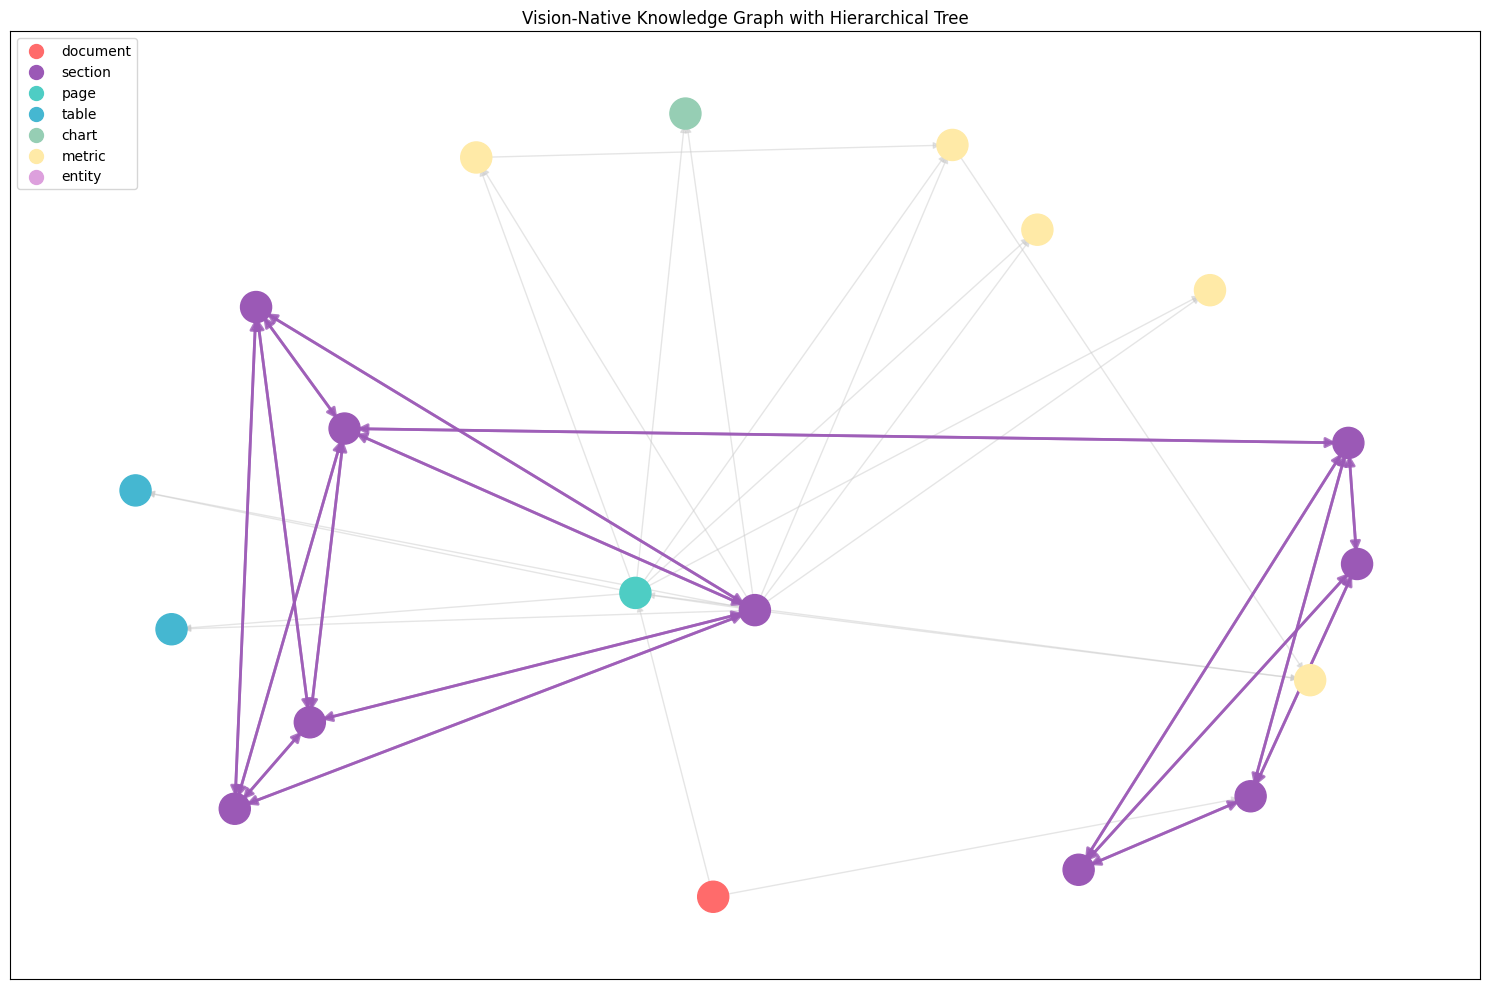

In [16]:
# Visualize the knowledge graph
import matplotlib.pyplot as plt
%matplotlib inline

try:
    pipeline.visualize_graph()
except Exception as e:
    print(f"Visualization error: {e}")
    print(f"\nGraph stats:")
    print(f"   Nodes: {pipeline.knowledge_graph.graph.number_of_nodes()}")
    print(f"   Edges: {pipeline.knowledge_graph.graph.number_of_edges()}")

## 9. Export Results

In [17]:
# Export extracted data to JSON
output_file = COOKBOOK_DIR / "vision_rag_output" / "extracted_data.json"
pipeline.export_to_json(str(output_file))

print(f"\n📁 Data exported to: {output_file}")

✅ Exported to /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook/vision_rag_output/extracted_data.json

📁 Data exported to: /home/sijo/VeritasGraph/graphrag-ollama-config/cookbook/vision_rag_output/extracted_data.json


## 10. Document Summary

In [18]:
# Show document summary
if doc and doc.document_summary:
    print("📝 Document Summary:")
    print("="*60)
    print(doc.document_summary)

📝 Document Summary:
<think>
Okay, let's tackle this query. The user wants a comprehensive summary of a document based on the provided page summaries. The page summaries mention a detailed analysis of the company's Q1 2024 performance, including revenue, growth, and performance metrics.

First, I need to figure out the document type and purpose. Since it's an analysis of Q1 2024 performance, the document is likely a quarterly report or financial analysis. The purpose would be to evaluate the company's performance, track growth, and provide insights for stakeholders.

Next, key findings. The user mentioned revenue, growth, and metrics. I should look for specific data points like revenue figures, growth percentages, maybe segment performance, and any notable trends. The summary should highlight these numbers and their implications.

Main topics covered would include revenue analysis, growth metrics, performance indicators, and possibly market conditions or strategic initiatives. I need to

---

## 🎉 Summary

This notebook demonstrated using the **VeritasGraph** package for Vision-Native RAG:

1. ✅ Imported `veritasgraph` package components
2. ✅ Configured the Vision RAG pipeline
3. ✅ Ingested a PDF document (Q4 2024 earnings report)
4. ✅ Queried the document with natural language
5. ✅ Explored extracted structure (tables, charts, metrics)
6. ✅ Visualized the knowledge graph
7. ✅ Exported results to JSON

### Install the package:
```bash
pip install veritasgraph
```

### Usage:
```python
from veritasgraph import VisionRAGPipeline, VisionRAGConfig

config = VisionRAGConfig(vision_model="llama3.2-vision:11b")
pipeline = VisionRAGPipeline(config)
doc = pipeline.ingest_pdf("document.pdf")
result = pipeline.query("Your question here")
```

### Links:
- **PyPI**: https://pypi.org/project/veritasgraph/
- **GitHub**: https://github.com/bibinprathap/VeritasGraph
- **Documentation**: https://bibinprathap.github.io/VeritasGraph/